# 작물 종류 추천 및 모델 성능 고도화
- 캐글 데이터 불러오기
- 데이터 확인 및 전처리
- 데이터 분리
- Tensor로 데이터 변환
- MLP 모델 구성
- 일반 MLP 모델과 고도화 모델을 비교
- Batch Normalization, Dropout, Weight Decay 적용
- Label Smoothing, Scheduler, Recall, F1-score
- 샘플 데이터로 예측

### 0. 라이브러리 불러오기

In [5]:
import copy
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import kagglehub

plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### 1. 데이터 불러오기

In [7]:
data_path = kagglehub.dataset_download(
    "atharvaingle/crop-recommendation-dataset",
    path = 'Crop_recommendation.csv')

df = pd.read_csv(data_path)

In [8]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


- 데이터 설명
    - N : 토양의 질소 성분
    - P : 토양의 인 성분
    - K : 토양의 칼륨 성분
    - temperature : 온도
    - humidity : 습도
    - ph : 토양의 PH
    - rainfall : 강수량
    - label : 추천 작물 종류

- 제대로 프로그램을 만든다면 지역, 위도, 경도, 계절, 토질, 병충해 같은 요소가 있으면 좋음

### 2. 데이터 확인 및 전처리

In [9]:
print(df.shape)
print(df.columns)
df.info()

(2200, 8)
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [10]:
# 컬럼명 앞뒤 공백 제거 후 소문자로 통일
df.columns = [
    column.strip().lower()
    for column in df.columns
]

df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [11]:
print(df.isnull().sum())

df.duplicated().sum()

n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


np.int64(0)

In [12]:
feature_columns = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
target_column = 'label'

X = df[feature_columns].copy()
y = df[target_column].copy()

print(X.shape, y.shape)


(2200, 7) (2200,)


In [13]:
# 작물 종류별 데이터 개수
class_counts = y.value_counts().sort_index()
print(f'작물의 클래스 종류: {y.nunique()}')

class_counts.to_frame(name= 'count')

작물의 클래스 종류: 22


,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


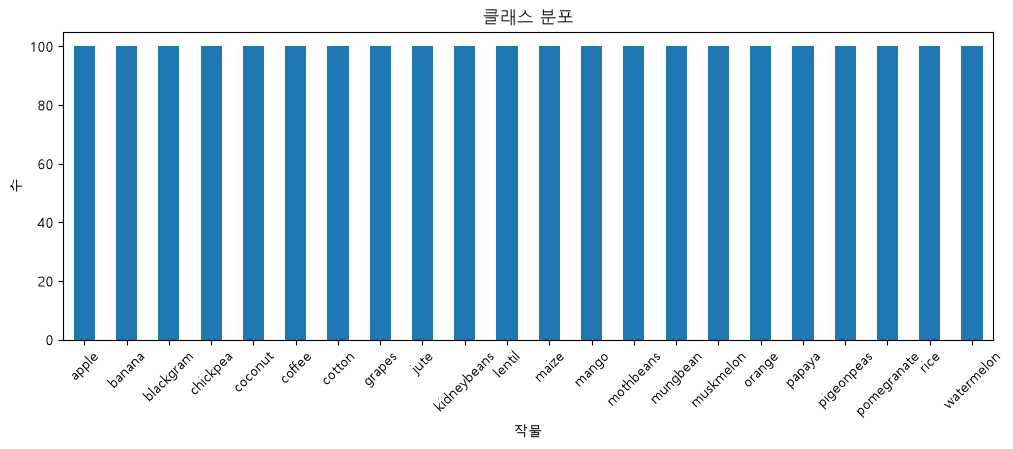

In [14]:
class_counts.plot(kind='bar', figsize=(12, 4))

plt.xlabel('작물')
plt.ylabel('수')
plt.title('클래스 분포')
plt.xticks(rotation=45)
plt.show()

In [15]:
# 라벨 인코딩  (0~ 클래스수 -1 정수로 변환)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = pd.DataFrame({
  'class_index' : range(len(label_encoder.classes_)),
  'crop' : label_encoder.classes_  
})

label_mapping


,class_index,crop
0,0,apple
1,1,banana
2,2,blackgram
3,3,chickpea
4,4,coconut
5,5,coffee
6,6,cotton
7,7,grapes
8,8,jute
9,9,kidneybeans


### 3. 학습/ 검증/ 테스트 데이터 분리

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size= 0.3,
    random_state=SEED,
    stratify= y_encoded,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size= 0.5,
    random_state=SEED,
    stratify= y_temp,
)

print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(1540, 7) (330, 7) (330, 7)
(1540,) (330,) (330,)


In [17]:
# 입력특성 표준화
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(X_train.mean().round(4))
print('--')

print(np.round(X_train_scaled.mean(axis=0), 4))


n               50.4558
p               53.2922
k               48.1286
temperature     25.5831
humidity        71.4399
ph               6.4698
rainfall       103.3550
dtype: float64
--
[ 0.  0.  0.  0. -0. -0. -0.]


In [41]:
X_train_tensor = torch.tensor(X_train_scaled, dtype= torch.float32)
y_train_tensor = torch.tensor(y_train, dtype= torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype= torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype= torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test, dtype= torch.float32)

In [42]:
print(X_train_tensor.shape, y_train_tensor.shape)
print(X_valid_tensor.shape, y_valid_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([1540, 7]) torch.Size([1540])
torch.Size([330, 7]) torch.Size([330])
torch.Size([330, 7]) torch.Size([330])


In [43]:
# 입력 텐서와 정답 텐서를 하나의 Dataset으로 묶기
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

# DataLoader로 미니배치 학습 준비(학습만 shuffle = True)
train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size= BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle=False)


print(f'학습 배치 수: {len(train_loader)}')
print(f'검증 배치 수: {len(valid_loader)}')
print(f'테스트 배치 수: {len(test_loader)}')

학습 배치 수: 25
검증 배치 수: 6
테스트 배치 수: 6


이진 분류 BCEWithLogitsLoss -> 모델 출력 설정에 따라 N 또는 (N, 1)  

다중 분류 CrossEntropyLoss ->  출력 (N) long   

회귀 : MSELoss -> (N, 1) float32


### 5. 딥러닝 모델 성능 고도화 전략
- 기본 모델 vs 고도화 모델 성능비교
    - 입력값 표준화
    - 은닉층 확장
    - Batch Normalization : 은닉층 출력분포 수치 안정
    - Dropout : 일부 뉴런 비활성화 -> 과적합 완화
    - Weight Decay  : 가중치 폭주 억제
    - Label Smoothing   : 정답 확신 완화
    - Learning Rate Scheduler : 개선없을 시 학습률 감소
    - Gradient Clipping : 기울기 폭주 억제
    - Early Stopping    : 개선없을시 학습 종료
    - Best Model Restore


### 6. 학습 및 검증 함수

In [45]:
import tqdm

In [64]:
# data_loader 에 대한 손실, 정확도, 예측값 계산하는 함수
def evaluate_model(model, data_loader, criterion):
    model.eval()        # 평가모드
    
    total_loss = 0      # 전체 손실
    
    # 전체 정답, 예측 클래스, 클래스별 확률
    all_targets = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)       # 장치로 이동
            batch_y = batch_y.to(device).long()       # 장치로 이동
            
            logits = model(batch_X)            # 순전파 : 클래스별 점수 계산
            loss = criterion(logits, batch_y)  # 예측 점수와 실제 정답을 비교해서 손실계산
            
            total_loss += loss.item() * batch_X.size(0)     # 전체 손실 : 미니배치 전체손실 * 미니배치 샘플 수
            
            probabilities = torch.softmax(logits, dim = 1)  # 클래스별 확률값 계산
            predictions = probabilities.argmax(dim= 1)      # 가장 높은 클래스 번호
            
            
            # extend 로 정답과 예측클래스, 확률갑을 하나의 리스트에 요소로서 풀어서 더해줌
            all_targets.extend(batch_y.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            
    average_loss = total_loss / len(data_loader.dataset)    # total_loss 를 전체 샘플수로 나눠 평균손실 계산
    
    accuracy = accuracy_score(all_targets, all_predictions)
    
    return average_loss, accuracy, np.array(all_targets), np.array(all_predictions), np.array(all_probabilities)
            
            

In [70]:
# 학습 및 검증 진행 함수
def train_model(model, train_loader, valid_loader, criterion, optimizer,
                epochs= 100, patience= 15, scheduler= None, gradient_clip= None):
    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_accuracy': [],
        'valid_accuracy': [],
        'lr': [],
    }
    
    best_valid_loss = float('inf')      # 최저 검증 손실 초기화
    best_model_state = None             # 최고 성능 모델
    
    patience_count = 0          # valid_loss 개선 없는 연속 에포크 수
    
    for epoch in tqdm.tqdm(range(1, epochs + 1)):
        model.train()
        
        total_train_loss = 0.0
        
        train_targets = []
        train_predictions = []
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)       # 장치로 이동
            batch_y = batch_y.to(device).long()       # 장치로 이동
            
            optimizer.zero_grad()              # 이전 미니배치에서 계산한 기울기 초기화
            logits = model(batch_X)            # 순전파 : 클래스별 점수 계산
            loss = criterion(logits, batch_y)  # 예측 점수와 실제 정답을 비교해서 손실계산
            loss.backward()                    # 역전파 : 기울기 계산
                                
            # 기울기 폭주 방지용                    
            if gradient_clip is not None:
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm= gradient_clip
                )
                
            optimizer.step()    # 계산된 기울기로 가중치 업데이트
            
            total_train_loss += (loss.item() * batch_X.size(0))
            
            predictions = logits.argmax(dim= 1)      # 가장 높은 logits를 가진 클래스 예측값으로 선택
            
            train_targets.extend(batch_y.cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())
            
        train_loss = total_train_loss / len(train_loader.dataset)           # 1 에포크의 평균 학습 손실
        train_accuracy = accuracy_score(train_targets, train_predictions)
        
        valid_loss, valid_accuracy, _, _, _ = evaluate_model(model, valid_loader, criterion)
        
        current_lr = optimizer.param_groups[0]["lr"]    # 현재의 학습률
        
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['valid_loss'].append(valid_loss)
        history['valid_accuracy'].append(valid_accuracy)
        history['lr'].append(current_lr)
        
        # Early Stopping
        # 개선 있을경우
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            
            best_model_state = copy.deepcopy(model.state_dict())
            
            patience_count = 0
        else:
            patience_count += 1
            
        if scheduler is not None:
            scheduler.step(valid_loss)
            
        if epoch == 1 or epoch % 10 ==0:
            print(f'Epoch : {epoch} | Train_loss : {train_loss:.4f}, Valid_loss : {valid_loss:.4f}, Train_Accuracy : {train_accuracy:.4f}, Valid_Accuracy : {valid_accuracy:.4f}, LR : {current_lr:.6f}')
            
        if patience_count >= patience:
            print(f'Epoch {epoch}에서 Early Stopping 동작함!')
            break
        
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history, best_valid_loss

In [ ]:
def count_parameters(model):
    return sum(
        # numel() : 텐서에 포함된 전체 원소수
        parameter.numel() for parameter in model.parameters() 
        if parameter.requires_grad  # 학습 대상 파라미터
    )
    
    
def calculatr_metrics(model, data_loader, criterion):
    loss, accuracy, targets, predictions, probabilities = evaluate_model(model, data_loader, criterion)
    
    metrics = {
        'Loss' : loss,
        "Accuracy" : accuracy,
        # macro : 각 클래스의 점수를 동일한 비중으로 평균을 낸다.
        "Macro Precision" :precision_score(targets, predictions, average= "macro", zero_division= 0),
        "Macro Recall" :recall_score(targets, predictions, average= "macro", zero_division= 0),
        "Macro F1-Score" :f1_score(targets, predictions, average= "macro", zero_division= 0),
        
        # weighted : 클래스별 데이터 수를 반영해서 평균
        "Weighted F1-Score" :f1_score(targets, predictions, average= "weighted", zero_division= 0),
    }
    
    return metrics, targets, predictions, probabilities



### 7. 기본 모델 학습
- 은닉층 64 -> 32
- 활성화 함수 ReLU
- 최적화 함수 Adam

In [72]:
input_size = X_train_tensor.size(1)
num_classes = len(label_encoder.classes_)

print(f'입력 특성 수 : {input_size} / 출력 클래스 수: {num_classes}')

입력 특성 수 : 7 / 출력 클래스 수: 22


In [73]:
# 기본 MLP 모델
class BaselineMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),     # 입력층 7 -> 은닉층 64
            nn.ReLU(),        # 비선형성 추가
            nn.Linear(64, 32),        # 은닉층1 64 -> 은닉층2 32
            nn.ReLU(),        # 비선형성 추가        
                    
            nn.Linear(32, num_classes)        # 은닉층1 32 -> 출력층
        )
        
    def forward(self, x):
        return self.network(x)
    
baseline_model = BaselineMLP(input_size= input_size, num_classes= num_classes).to(device)
print(baseline_model)
print(f'학습 가능할 파라미터의 수 : {count_parameters(baseline_model)}')

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능할 파라미터의 수 : 3318


In [74]:
baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr= 0.001)

baseline_history, baseline_best_valid_loss = train_model(
    model = baseline_model, 
    train_loader = train_loader,
    valid_loader= valid_loader, 
    criterion = baseline_criterion,
    optimizer= baseline_optimizer,
    epochs= 300,
    patience= 15, )

print( f'기존 모델 최저 검증 손실 : {baseline_best_valid_loss:.4f}')

  0%|          | 1/300 [00:01<05:04,  1.02s/it]

Epoch : 1 | Train_loss : 3.0460, Valid_loss : 2.9576, Train_Accuracy : 0.0818, Valid_Accuracy : 0.1636, LR : 0.001000


  4%|▎         | 11/300 [00:03<00:58,  4.91it/s]

Epoch : 10 | Train_loss : 0.5066, Valid_loss : 0.4614, Train_Accuracy : 0.8916, Valid_Accuracy : 0.9091, LR : 0.001000


  7%|▋         | 20/300 [00:05<01:21,  3.45it/s]

...

Epoch : 140 | Train_loss : 0.0153, Valid_loss : 0.0235, Train_Accuracy : 0.9961, Valid_Accuracy : 0.9939, LR : 0.001000


 50%|█████     | 151/300 [00:42<00:55,  2.67it/s]

Epoch : 150 | Train_loss : 0.0149, Valid_loss : 0.0222, Train_Accuracy : 0.9961, Valid_Accuracy : 0.9939, LR : 0.001000


 52%|█████▏    | 157/300 [00:45<00:41,  3.42it/s]

Epoch 158에서 Early Stopping 동작함!
기존 모델 최저 검증 손실 : 0.0220


In [75]:
# 기본 MLP 모델
class ImprovedMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),     # 입력층 7 -> 은닉층 64
            nn.BatchNorm1d(128),
            nn.ReLU(),        # 비선형성 추가
            
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),     
            nn.BatchNorm1d(64),
            nn.ReLU(),        # 비선형성 추가
            
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),        # 
            nn.ReLU(),        # 비선형성 추가        
                    
            nn.Linear(32, num_classes)        # 은닉층1 32 -> 출력층
        )
        
    def forward(self, x):
        return self.network(x)
    
improved_model = ImprovedMLP(input_size= input_size, num_classes= num_classes).to(device)
print(improved_model)
print(f'학습 가능할 파라미터의 수 : {count_parameters(improved_model)}')

ImprovedMLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=22, bias=True)
  )
)
학습 가능할 파라미터의 수 : 12470


In [76]:
# Label Smoothing : 정답 클래스 대한 확신을 5% 줄임 => 일반화 성능 향상
improved_criterion = nn.CrossEntropyLoss(label_smoothing= 0.05)

# AdamW weight_decay : 가중치가 지나치게 커지는 것을 억제
improved_optimizer = torch.optim.AdamW(improved_model.parameters(), lr= 0.001, weight_decay= 0.0001)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer,
    mode = 'min',       # 검증 손실기준 작아지는 방향을 개선으로 판단
    factor = 0.5,       # 학습률은 절반으로 감소
    patience= 5,        # 5회 동안 개선 없으면 학습률 감소
    min_lr = 1e-5       # 학습률 최소값
)

improved_history, improved_best_valid_loss = train_model(
    model = improved_model,
    train_loader= train_loader,
    valid_loader = valid_loader,
    criterion= improved_criterion,
    optimizer= improved_optimizer,
    epochs= 1000,
    patience= 15,
    scheduler= scheduler,
    gradient_clip= 1.0
)

  0%|          | 1/1000 [00:00<10:44,  1.55it/s]

Epoch : 1 | Train_loss : 2.9504, Valid_loss : 2.7519, Train_Accuracy : 0.1662, Valid_Accuracy : 0.3788, LR : 0.001000


  1%|          | 10/1000 [00:04<04:51,  3.39it/s]

Epoch : 10 | Train_loss : 0.7921, Valid_loss : 0.6041, Train_Accuracy : 0.8864, Valid_Accuracy : 0.9818, LR : 0.001000


  2%|▏         | 20/1000 [00:07<04:25,  3.69it/s]

...

Epoch : 100 | Train_loss : 0.4924, Valid_loss : 0.4094, Train_Accuracy : 0.9688, Valid_Accuracy : 0.9939, LR : 0.000125


 11%|█         | 110/1000 [00:35<03:37,  4.09it/s]

Epoch : 110 | Train_loss : 0.4810, Valid_loss : 0.4057, Train_Accuracy : 0.9753, Valid_Accuracy : 0.9939, LR : 0.000031


 11%|█         | 111/1000 [00:36<04:48,  3.08it/s]

Epoch 112에서 Early Stopping 동작함!


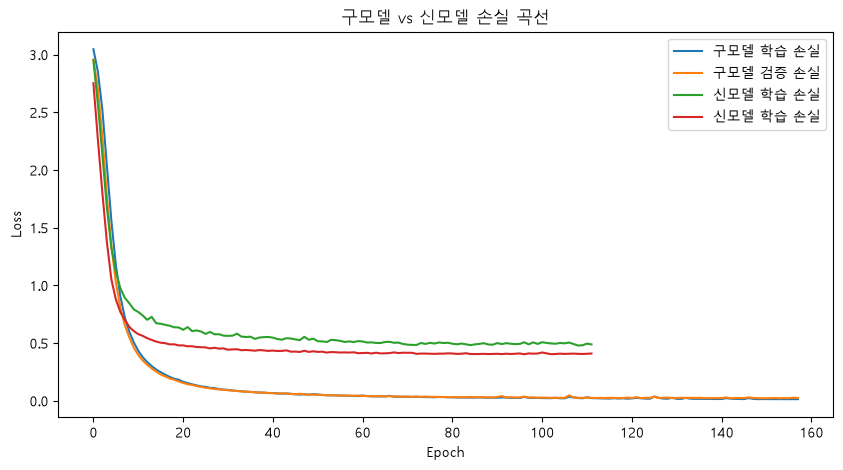

In [77]:
# 기존 모델과 고도화 모델 학습 및 검증 손실 비교 시각화
plt.figure(figsize= (10, 5))

plt.plot(baseline_history['train_loss'], label= '구모델 학습 손실')
plt.plot(baseline_history['valid_loss'], label= '구모델 검증 손실')

plt.plot(improved_history['train_loss'], label= '신모델 학습 손실')
plt.plot(improved_history['valid_loss'], label= '신모델 학습 손실')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('구모델 vs 신모델 손실 곡선')
plt.legend()
plt.show()

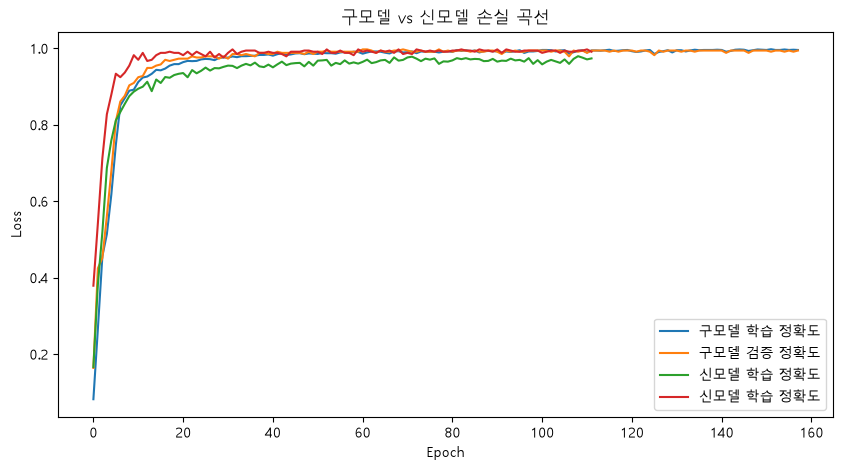

In [78]:
# 기존 모델과 고도화 모델 학습 및 검증 손실 비교 시각화
plt.figure(figsize= (10, 5))

plt.plot(baseline_history['train_accuracy'], label= '구모델 학습 정확도')
plt.plot(baseline_history['valid_accuracy'], label= '구모델 검증 정확도')

plt.plot(improved_history['train_accuracy'], label= '신모델 학습 정확도')
plt.plot(improved_history['valid_accuracy'], label= '신모델 학습 정확도')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('구모델 vs 신모델 손실 곡선')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize= (10, 5))

plt.plot(baseline_history['train_accuracy'], label= '구모델 학습 정확도')
plt.plot(baseline_history['valid_accuracy'], label= '구모델 검증 정확도')

plt.plot(improved_history['train_accuracy'], label= '신모델 학습 정확도')
plt.plot(improved_history['valid_accuracy'], label= '신모델 학습 정확도')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('구모델 vs 신모델 손실 곡선')
plt.legend()
plt.show()

### 10. 테스트 데이터로 최종 평가


In [81]:
baseline_metrics, baseline_targets, baseline_predictions, _ = calculatr_metrics(
    baseline_model,
    test_loader,
    baseline_criterion
)

improved_metrics, test_targets, test_predictions, _ = calculatr_metrics(
    improved_model,
    test_loader,
    improved_criterion
)

comparison_df = pd.DataFrame({
    'Baseline Model' : baseline_metrics,
    'Improved Model' : improved_metrics
})

comparison_df.round(4)

,Baseline Model,Improved Model
Loss,0.0200,0.4056
Accuracy,0.9909,0.9909
Macro Precision,0.9911,0.9918
Macro Recall,0.9909,0.9909
Macro F1-Score,0.9909,0.9909
Weighted F1-Score,0.9909,0.9909


loss는 떨어질 수 있어도 일반화 성능 향상 목적을 달성한 모습을 보임

In [82]:
report = classification_report(
    test_targets,
    test_predictions,
    labels = range(num_classes),
    target_names = label_encoder.classes_,
    output_dict = True,
    zero_division= 0
)

report_df = pd.DataFrame(report).T
report_df.round(4)

,precision,recall,f1-score,support
apple,1.0000,1.0000,1.0000,15.0000
banana,1.0000,1.0000,1.0000,15.0000
blackgram,1.0000,1.0000,1.0000,15.0000
chickpea,1.0000,1.0000,1.0000,15.0000
coconut,1.0000,1.0000,1.0000,15.0000
coffee,1.0000,1.0000,1.0000,15.0000
cotton,1.0000,1.0000,1.0000,15.0000
grapes,1.0000,1.0000,1.0000,15.0000
jute,0.8824,1.0000,0.9375,15.0000
kidneybeans,1.0000,1.0000,1.0000,15.0000


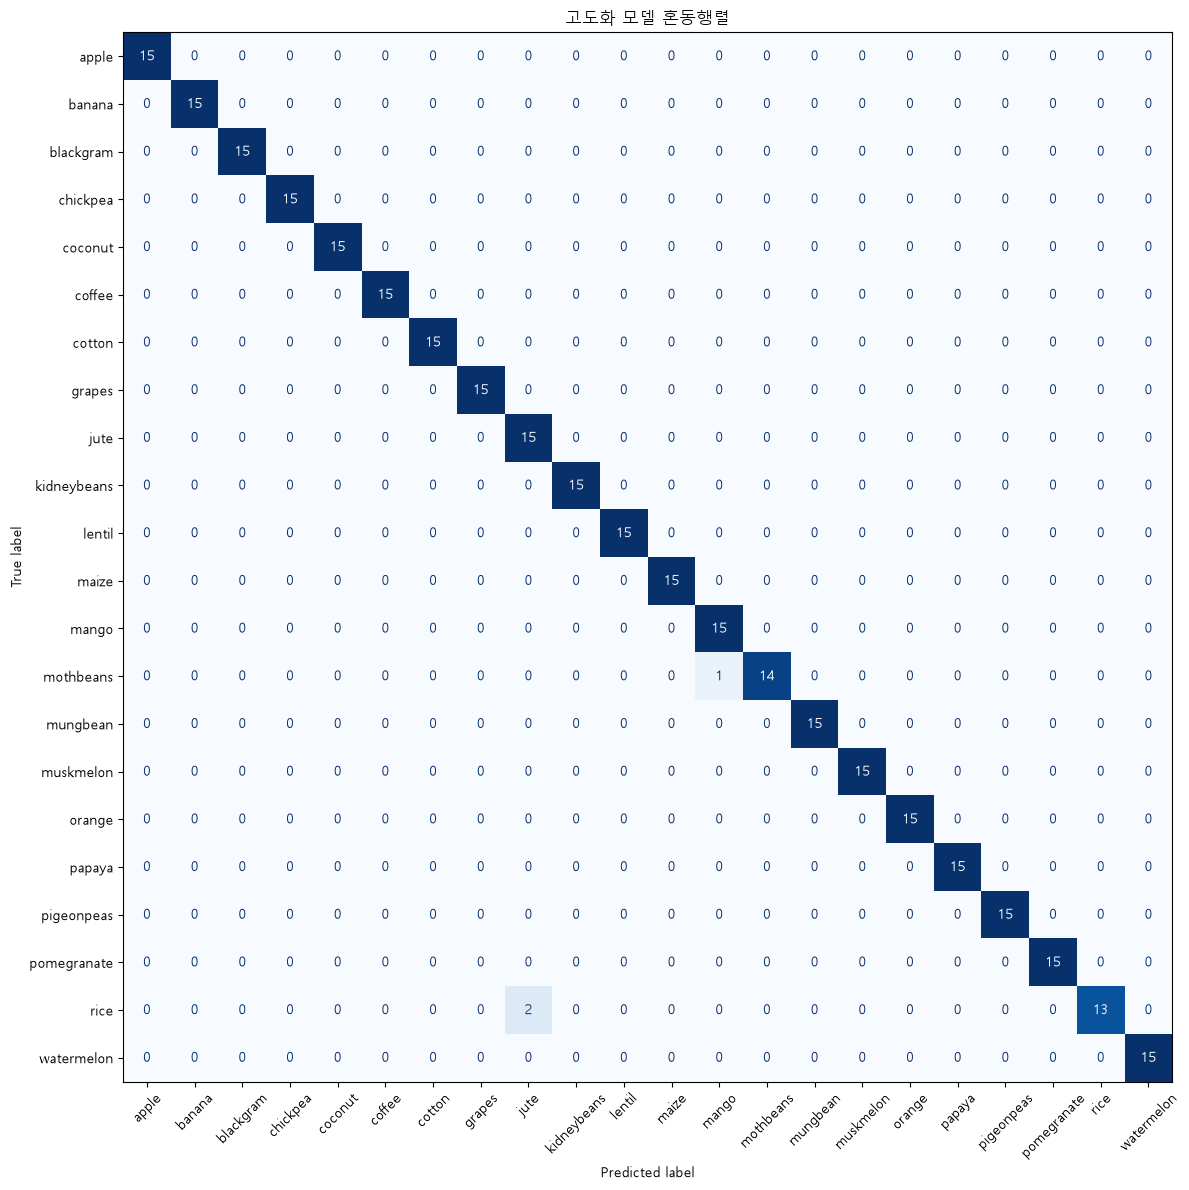

In [ ]:
# 혼동행렬 
fig, axes = plt.subplots(figsize= (14, 12))

ConfusionMatrixDisplay.from_predictions(
    test_targets,           # 행은 실제값
    test_predictions,       # 열은 예측값
    display_labels = label_encoder.classes_,
    xticks_rotation=45,
    cmap= 'Blues',
    colorbar= False,
    ax= axes
)

plt.title('고도화 모델 혼동행렬')
plt.tight_layout()
plt.show()

### 11. 최적 모델과 전처리 도구 저장

In [ ]:
# 학습된 Pytorch모델의 가중치와 모델 복원시 필요한 설정 저장
torch.save(
    {
        'model_state_dict' : improved_model.state_dict(),   # best 모델의 가중치와 편향
        
        # 모델 구조 재구성시 필요한 입력과 출력크기
        'input_size' : input_size,
        'num_classes' : num_classes,
        
        # 예측시 동일한 입력순서 유지용 컬럼 목록
        'feature_columns' : feature_columns,
        # 클래스 번호를 작물 이름으로 복원하기 위한 클래스 목록
        'class_names' : label_encoder.classes_.tolist(),
    },
    'crop_improved_model.pth'   # 저장경로
)

# 학습시에 사용한 스케일러 저장
joblib.dump(scaler, 'crop_scaler.pkl')
# 숫자클래스와 작물 이름 변환 규칙 저장
joblib.dump(label_encoder, 'crop_label_encoder.pkl')

print('모델 및 전처리 도구 저장 완료')


모델 및 전처리 도구 저장 완료


### 12. 새로운 샘플 데이터로 작물 추천 받기


In [88]:
df.columns

Index(['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [ ]:
def reccomend_crop(n, p, k, temperature,humidity,ph,rainfall, top_k = 3):
    sample = pd.DataFrame(
        [[n, p, k, temperature,humidity,ph,rainfall]],  # (batch, 특성 수)
        columns= feature_columns
    )
    
    sample_scaled = scaler.transform(sample)
    
    sample_tensor = torch.FloatTensor(sample_scaled).to(device)
    
    improved_model.eval()
    with torch.no_grad():
        logits = improved_model(sample_tensor)
        
        probabilities = torch.softmax(logits, dim=1)[0]
        
        top_probabilities, top_indices = torch.topk(probabilities, k= top_k)
        
        crobs = label_encoder.inverse_transform(top_indices.cpu().numpy())
        
        result = pd.DataFrame({
            'crob' : crobs,
            'probability' : (top_probabilities.cpu().numpy()*100).round(2)
        })
        
        return result

In [91]:
sample_row = df.iloc[0]

print(f'실제 작물 : {sample_row['label']}')

reccomend_crop(
    n = sample_row['n'],
    p = sample_row['p'],
    k = sample_row['k'],
    
    temperature= sample_row['temperature'],
    humidity= sample_row['humidity'],
    ph=  sample_row['ph'],
    rainfall = sample_row['rainfall'],
    top_k= 3
)

실제 작물 : rice


ValueError: 7 columns passed, passed data had 8 columns